Loading dataset...
Loading images from Bengin...


  0%|          | 0/120 [00:00<?, ?it/s]

100%|██████████| 120/120 [00:00<00:00, 252.45it/s]


Loading images from Malignant...


100%|██████████| 561/561 [00:02<00:00, 270.34it/s]


...

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 18s 581ms/step - accuracy: 0.5250 - loss: 1.3968 - val_accuracy: 0.6727 - val_loss: 0.6963
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 562ms/step - accuracy: 0.6985 - loss: 0.6850 - val_accuracy: 0.8227 - val_loss: 0.3855
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 560ms/step - accuracy: 0.8596 - loss: 0.3536 - val_accuracy: 0.9273 - val_loss: 0.1904
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 564ms/step - accuracy: 0.9297 - loss: 0.1729 - val_accuracy: 0.9000 - val_loss: 0.2657
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 581ms/step - accuracy: 0.9317 - loss: 0.1826 - val_accuracy: 0.9682 - val_loss: 0.0883
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 592ms/step - accuracy: 0.9731 - loss: 0.0815 - val_accuracy: 0.9864 - val_loss: 0.0395
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 595ms/step - accuracy: 0.9834 - loss: 0.0480 - val_accuracy: 0.9818 - val_loss: 0.0335
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 594ms/step - accuracy: 0.9830 - loss: 0.0568 - val_accu

Final Validation Accuracy: 1.0000
Final Validation Loss: 0.0101


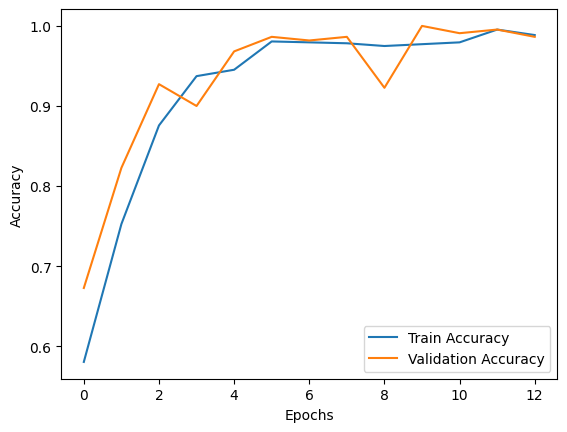

In [36]:
# Import necessary libraries
import os
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

# Set dataset path
DATASET_PATH = "../dataset"

# Define categories (must match folder names)
CATEGORIES = ["Bengin", "Malignant", "Normal"]

# Image size for resizing
IMG_SIZE = 224

# Function to load images and labels
def load_data():
    X, Y = [], []

    for label, category in enumerate(CATEGORIES):
        folder_path = os.path.join(DATASET_PATH, category)
        print(f"Loading images from {category}...")

        for img_name in tqdm(os.listdir(folder_path)):
            img_path = os.path.join(folder_path, img_name)

            try:
                # Read image and resize
                img = cv2.imread(img_path)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img / 255.0  # Normalize

                X.append(img)
                Y.append(label)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

    return np.array(X), np.array(Y)

# Load dataset
print("Loading dataset...")
X, Y = load_data()

# Convert labels to categorical (one-hot encoding)
Y_cat = to_categorical(Y, num_classes=3)

# Split dataset into training (80%) and validation (20%)
X_train, X_val, Y_train_cat, Y_val_cat = train_test_split(X, Y_cat, test_size=0.2, random_state=42, stratify=Y)

print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}")

# Build CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')  # Output layer with 3 classes
])

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

# Define EarlyStopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, Y_train_cat,
    validation_data=(X_val, Y_val_cat),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate model
loss, accuracy = model.evaluate(X_val, Y_val_cat)
print(f"Final Validation Accuracy: {accuracy:.4f}")
print(f"Final Validation Loss: {loss:.4f}")

# Save the trained model
model.save("lung_cancer_model.h5")

# Plot accuracy graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()



In [37]:
val_loss, val_acc = model.evaluate(X_val, Y_val_cat, verbose=1)
print(f"Final Validation Accuracy: {val_acc:.4f}")
print(f"Final Validation Loss: {val_loss:.4f}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 1.0000 - loss: 0.0085
Final Validation Accuracy: 1.0000
Final Validation Loss: 0.0101


In [38]:
model.save("lung_cancer_model.h5")
print("Model saved successfully!")


Model saved successfully!


In [44]:
import os
import numpy as np
import cv2
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, classification_report

# Define test data path
TEST_PATH = "../dataset/Test"

# Define class labels
class_labels = ["Benign", "Malignant", "Normal"]

# Function to load and preprocess test images
def load_test_images(test_path, img_size=(224, 224)):
    test_images = []
    test_filenames = []
    
    for img_name in os.listdir(test_path):
        img_path = os.path.join(test_path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.resize(img, img_size)
        img = img / 255.0  # Normalize
        test_images.append(img)
        test_filenames.append(img_name)
    
    return np.array(test_images), test_filenames

# Load test images
X_test, test_filenames = load_test_images(TEST_PATH)

# Check shape
print(f"Test Data Shape: {X_test.shape}")

# Load the trained model
model = load_model("../lung_cancer_model.h5")

# Predict on test data
predictions = model.predict(X_test)

# Convert predictions to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Print predictions for each test image
for filename, label in zip(test_filenames, predicted_labels):
    print(f"Image: {filename} → Predicted: {class_labels[label]}")

# If test set has ground truth labels (Y_test), calculate accuracy
# Assuming you have corresponding labels for the test set
# Y_test should be a list of integers (0: Benign, 1: Malignant, 2: Normal)
try:
    Y_test = [...]  # Replace with actual test labels if available
    accuracy = accuracy_score(Y_test, predicted_labels)
    print(f"\nTest Accuracy: {accuracy:.4f}")

    # Print classification report
    print("\nClassification Report:\n", classification_report(Y_test, predicted_labels, target_names=class_labels))
except:
    print("\nNo ground truth labels available for accuracy calculation.")

# Save the trained model
model.save("lung_cancer_model.h5")
print("Model saved successfully!")


Test Data Shape: (197, 224, 224, 3)
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step


Image: 000001_03_01_088.png → Predicted: Malignant
Image: 000017_02_01_016.png → Predicted: Malignant
Image: 000019_01_01_021.png → Predicted: Malignant
Image: 000019_02_01_025.png → Predicted: Normal
Image: 000019_03_01_025.png → Predicted: Malignant
Image: 000020_01_01_066.png → Predicted: Normal
Image: 000020_02_01_062.png → Predicted: Malignant
Image: 000020_03_01_134.png → Predicted: Malignant
Image: 000020_03_01_166.png → Predicted: Malignant
Image: 000020_03_01_212.png → Predicted: Malignant
Image: 000020_04_01_116.png → Predicted: Normal
Image: 000020_04_01_143.png → Predicted: Normal
Image: 000020_04_01_159.png → Predicted: Malignant
Image: 000021_01_01_016.png → Predicted: Malignant
Image: 000021_02_01_068.png → Predicted: Malignant
Image: 000021_03_01_012.png → Predicted: Normal
Image: 000021_03_01_017.png → Predicted: Normal
Image: 000021_04_01_090.png → Predicted: Malignant
Image: 000027_01_01_113.png → Predicted: Malignant
Image: 000027_02_01_105.png → Predicted: Normal
I

In [45]:
model.save('lung_cancer_model.keras')

